
Solving data_32.xml (Nodes: 32)
Iter    0, Min: 1448.1331, Mean: 1741.2899, Max: 1964.7714
Iter   10, Min: 1115.1509, Mean: 1315.0436, Max: 1530.7210
Iter   20, Min: 986.4160, Mean: 1275.1212, Max: 1576.9084
Iter   30, Min: 1123.1586, Mean: 1299.2732, Max: 1517.9666
Iter   40, Min: 1179.4979, Mean: 1308.3275, Max: 1597.4683
Iter   50, Min: 1031.7774, Mean: 1257.1752, Max: 1475.4733
Iter   60, Min: 1163.9953, Mean: 1313.2110, Max: 1475.2305
Iter   70, Min: 1118.8466, Mean: 1285.7543, Max: 1646.1203
Iter   80, Min: 1048.2610, Mean: 1267.8862, Max: 1578.0889
Iter   90, Min: 1176.4831, Mean: 1266.6326, Max: 1398.6222
Iter   99, Min: 1148.4351, Mean: 1303.2305, Max: 1510.6601

Total Distance (Cost): 938.94
Total Vehicles Used: 5

Route 1: [1, 31, 27, 17, 13, 2, 4, 24, 9, 19, 23, 1]
Route 2: [1, 21, 6, 26, 11, 16, 30, 15, 25, 1]
Route 3: [1, 8, 14, 22, 32, 20, 18, 1]
Route 4: [1, 7, 3, 12, 5, 29, 10, 1]
Route 5: [1, 28, 1]


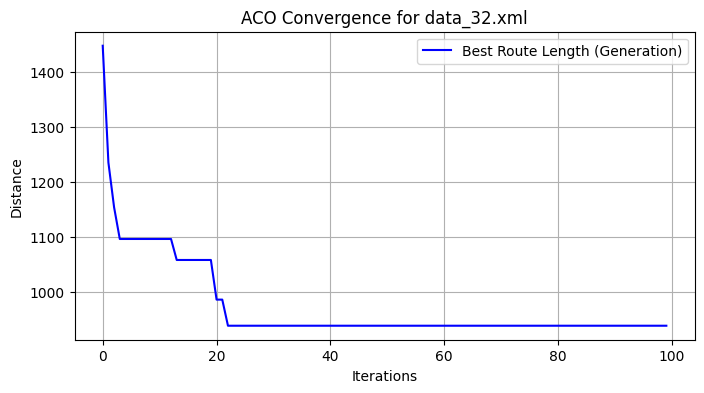


Solving data_72.xml (Nodes: 72)
Iter    0, Min: 435.6914, Mean: 521.8003, Max: 652.3041
Iter   10, Min: 364.7347, Mean: 451.2759, Max: 551.4683
Iter   20, Min: 304.6979, Mean: 427.5738, Max: 514.4056
Iter   30, Min: 339.2503, Mean: 432.0493, Max: 585.6842
Iter   40, Min: 378.1069, Mean: 433.6856, Max: 531.5213
Iter   50, Min: 353.0090, Mean: 439.9523, Max: 535.8008
Iter   60, Min: 349.7134, Mean: 434.2460, Max: 541.4970
Iter   70, Min: 364.0703, Mean: 431.4414, Max: 598.2455
Iter   80, Min: 346.8280, Mean: 431.8160, Max: 531.1930
Iter   90, Min: 383.6995, Mean: 440.3651, Max: 586.8317
Iter  100, Min: 338.3806, Mean: 433.1446, Max: 548.1270
Iter  110, Min: 344.5073, Mean: 439.8532, Max: 594.0531
Iter  120, Min: 374.2972, Mean: 454.4204, Max: 579.7578
Iter  130, Min: 361.3886, Mean: 445.1288, Max: 560.3332
Iter  140, Min: 336.8039, Mean: 444.3366, Max: 514.3217
Iter  150, Min: 327.6108, Mean: 442.1772, Max: 518.3503
Iter  160, Min: 369.1307, Mean: 437.3486, Max: 529.9727
Iter  170, Min:

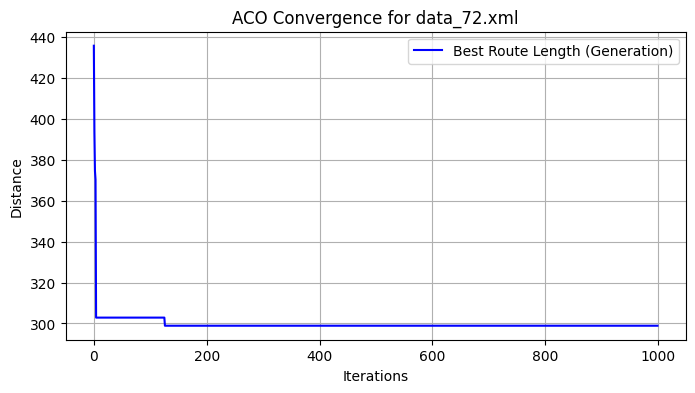


Solving data_422.xml (Nodes: 421)
Iter    0, Min: 3345.7987, Mean: 3742.2288, Max: 3965.2941
Iter   10, Min: 2904.7971, Mean: 3169.7722, Max: 3491.6887
Iter   20, Min: 2995.5579, Mean: 3211.4771, Max: 3544.8857
Iter   30, Min: 3106.3715, Mean: 3325.9192, Max: 3598.2534
Iter   40, Min: 3078.0910, Mean: 3273.2774, Max: 3506.4933
Iter   49, Min: 2969.2356, Mean: 3242.6489, Max: 3496.7871

Total Distance (Cost): 2731.72
Total Vehicles Used: 38

Route 1: [421, 157, 102, 162, 217, 124, 150, 99, 40, 41, 100, 101, 155, 96, 36, 421]
Route 2: [421, 22, 3, 29, 89, 34, 35, 94, 149, 142, 91, 82, 31, 32, 33, 28, 421]
Route 3: [421, 5, 38, 98, 47, 65, 105, 50, 51, 111, 110, 165, 117, 421]
Route 4: [421, 14, 2, 62, 81, 26, 27, 86, 141, 146, 201, 147, 88, 421]
Route 5: [421, 92, 93, 152, 262, 211, 322, 271, 144, 143, 194, 122, 134, 83, 74, 421]
Route 6: [421, 46, 55, 106, 6, 53, 113, 58, 66, 126, 178, 233, 421]
Route 7: [421, 202, 151, 183, 209, 154, 95, 156, 69, 161, 220, 279, 330, 421]
Route 8: [421

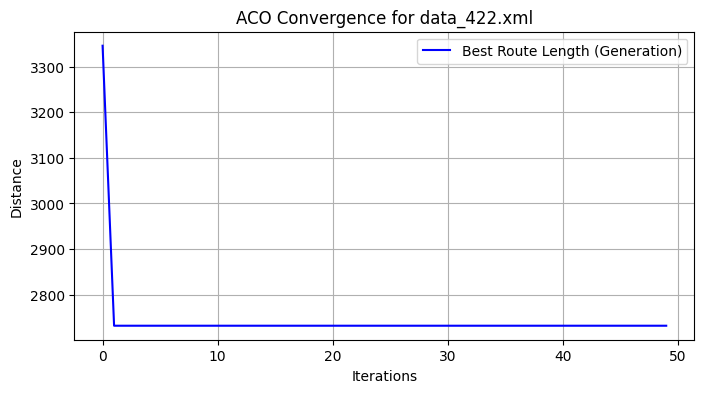

In [ ]:
import xml.etree.ElementTree as ET
import math
import functools
import numpy as np
import matplotlib.pyplot as plt
from collections import namedtuple

Node = namedtuple('Node', ['id', 'type', 'x', 'y', 'demand'])

def load_vrp_xml(filepath):
    tree = ET.parse(filepath)
    root = tree.getroot()

    nodes = {}
    depot_id = None
    capacity = float(root.find('fleet').find('vehicle_profile').find('capacity').text)

    for n in root.find('network').find('nodes'):
        n_id = int(n.attrib['id'])
        n_type = int(n.attrib['type'])
        cx = float(n.find('cx').text)
        cy = float(n.find('cy').text)
        nodes[n_id] = Node(id=n_id, type=n_type, x=cx, y=cy, demand=0.0)
        if n_type == 0:
            depot_id = n_id

    for req in root.find('requests'):
        node_id = int(req.attrib['node'])
        quant = float(req.find('quantity').text)
        old = nodes[node_id]
        nodes[node_id] = Node(id=old.id, type=old.type, x=old.x, y=old.y, demand=quant)

    return nodes, depot_id, capacity

@functools.lru_cache(maxsize=None)
def distance(v1, v2):
    return math.sqrt((v1.x - v2.x)**2 + (v1.y - v2.y)**2)

def fitness(nodes, dist, sol):
    sd = 0
    for x, y in zip(sol, sol[1:]):
        sd += dist(nodes[x], nodes[y])
    return sd

def initialize_pheromone(N):
    return 0.01 * np.ones(shape=(N, N))

def generate_solutions(nodes, depot_id, capacity, P, dist, N, alpha=1, beta=3):
    def compute_prob(v1, v2):
        d = max(dist(nodes[v1], nodes[v2]), 0.00001)
        nu = 1 / d
        tau = P[v1, v2]
        ret = pow(tau, alpha) * pow(nu, beta)
        return ret if ret > 0.000001 else 0.000001

    for i in range(N):
        available = [n.id for n in nodes.values() if n.type == 1]
        sol = [depot_id]
        current_capacity = capacity

        while available:
            feasible = [x for x in available if nodes[x].demand <= current_capacity]

            if not feasible:
                sol.append(depot_id)
                current_capacity = capacity
                continue

            probs = np.array(list(map(lambda x: compute_prob(sol[-1], x), feasible)))
            prob_sum = sum(probs)

            selected = np.random.choice(feasible, p=probs/prob_sum)
            sol.append(selected)
            available.remove(selected)
            current_capacity -= nodes[selected].demand

        sol.append(depot_id)
        yield sol

def update_pheromone(P, sols, fits, Q=100, rho=0.8):
    ph_update = np.zeros(shape=P.shape)
    for s, f in zip(sols, fits):
        for x, y in zip(s, s[1:]):
            ph_update[x][y] += Q/f
            ph_update[y][x] += Q/f

    return (1-rho)*P + ph_update

def ant_solver(nodes, depot_id, capacity, dist, ants=10, max_iter=100, alpha=1, beta=3, Q=100, rho=0.8):
    max_id = max(nodes.keys())
    P = initialize_pheromone(max_id + 1)
    best_sol = None
    best_fit = float('inf')

    log_min = []

    for it in range(max_iter):
        sols = list(generate_solutions(nodes, depot_id, capacity, P, dist, ants, alpha=alpha, beta=beta))
        fits = list(map(lambda x: fitness(nodes, dist, x), sols))
        P = update_pheromone(P, sols, fits, Q=Q, rho=rho)

        for s, f in zip(sols, fits):
            if f < best_fit:
                best_fit = f
                best_sol = s

        min_fit = np.min(fits)
        log_min.append(best_fit)

        if it % 10 == 0 or it == max_iter - 1:
            print(f'Iter {it:4}, Min: {min_fit:.4f}, Mean: {np.mean(fits):.4f}, Max: {np.max(fits):.4f}')

    return best_sol, best_fit, log_min

if __name__ == '__main__':
    files = ['data_32.xml', 'data_72.xml', 'data_422.xml']

    for file in files:
        try:
            nodes, depot_id, capacity = load_vrp_xml(file)
            print(f"\n{'='*50}\nSolving {file} (Nodes: {len(nodes)})\n{'='*50}")

            if len(nodes) < 50:
                iters = 100
                ant_count = 20
                a = 1.0
                b = 3.0
                q_val = 100
                evap = 0.8
            elif len(nodes) < 100:
                iters = 1000
                ant_count = 50
                a = 1.0
                b = 3.0
                q_val = 100
                evap = 0.8
            else:
                iters = 50
                ant_count = 20
                a = 1.0
                b = 3.0
                q_val = 100
                evap = 0.8

            best_sol, best_fit, log_min = ant_solver(
                nodes, depot_id, capacity, distance,
                ants=ant_count, max_iter=iters, alpha=a, beta=b, Q=q_val, rho=evap
            )

            routes = []
            current_route = [depot_id]
            for node in best_sol[1:]:
                current_route.append(node)
                if node == depot_id:
                    if len(current_route) > 2:
                        routes.append(current_route)
                    current_route = [depot_id]

            print(f"\nTotal Distance (Cost): {best_fit:.2f}")
            print(f"Total Vehicles Used: {len(routes)}\n")

            for i, route in enumerate(routes, 1):
                clean_route = [int(n) for n in route]
                print(f"Route {i}: {clean_route}")

            plt.figure(figsize=(8, 4))
            plt.plot(log_min, 'b-', label="Best Route Length (Generation)")
            plt.title(f"ACO Convergence for {file}")
            plt.xlabel("Iterations")
            plt.ylabel("Distance")
            plt.grid(True)
            plt.legend(loc="best")
            plt.show()

        except FileNotFoundError:
            print(f"Warning: {file} not found. Please ensure it is in the same directory.")

In this assignment I mainly used the implementation of ACO we had in the tutorials. I kept the parameters and the structure of the implementation as similar as possible and modified/adapted the functions and the logic according to the assignment requirements.

** The Adaptations I had:**

I expanded the standard **Vertex** tuple we had in the lab to a **Node** tuple as required in the task. My new node tuple includes deman and type attributes to detect the difference between a customer and a depot. I also implemented an XML parser to get the coordinates for of the nodes, capacities and requests.

For Route Generation, I changed the way of how ants work. Now they track their **current_capacity**. They filter the customers so they can find best stops. If the deman exceeds the remaining capacity, the ant is forced to append the **depot_id** to its route. (Penalty)

For Fitness Function and Minimization, the fitness score is now based on the total travel distance.

Pheromone Updates: I adjusted the logic of **update_pheromone** to represent the undirected edges get the equal reinforcment accorrding to the type.

**Algorithm Code and Instructions**

1) Place the three data files in the same directory as this Jupyter Notebook

2) Install the libraries required (nupy, matplotlib)

3) Run the Python cell. The algorithm will solve the instances and print the best routes and produce the graphs accordingly.

**AI Usage**

I implemented the code myself but got some help from ChatGPT and Gemini to understand the logic behind the xml.etree.Element parsing logic to extract coordinates and demands from the provided .xml datasets. I asked the structure and working logic as well as some examples and how one can implement such thing. After I understood everything I implemented my code accordingly.

Additionally I spent some time on understanding the pheromone math because my first implementations crashed on massive datasets like 422-node map, when I applied the extra penalties to the fitness function. I got a little help for some debugging for this issue. Once I understood I fixed my implemetation and made sure I purely relied on the distance.

I did not use any AI tools except for these specific points. I did not copy-paste any code, nor did I implement any code without fully understanding how it works and the logic behind it. I also conducted independent online research on how these algorithms are structured, using AI strictly as a tutor to solidify my understanding.

